---
title: Linear Algebra
short_title: Matrices

numbering:
  headings: false

numbered_references: false
---

This chapter will help you get consolidate your knowledge of linear algebra. To solve the exercises in this section you will need to have some basic understanding of:

- numpy arrays
- loops and if statements
- functions


# Matrices 

In the previous section, we saw how to do linear combination of vectors $v$ and $w$ as described in the equation below.

$cv + dw = b$

with c and d as scalars and b as a resulting vector.

Notice that to do that, we had to operate on each vector before combine them through addition. However, one can see that operation from a slightly different perspective if we combine the two vectors beforehand, in a kind of vector of vectors. 

Let's see this example using the vectors $v = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ and $w = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$ (Notice that we are representing the vectors as column-vectors in order to facilitate the visualization of the equations).

The linear combination then becomes:

$ c \begin{bmatrix} 1 \\ -1 \end{bmatrix} + d \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} c \\ d - c  \end{bmatrix}$

If we stack the two vectors inside another vector we get:

$A = \begin{bmatrix} ~  \\ v & w \\ ~ \end{bmatrix} = \begin{bmatrix} \begin{bmatrix} 1 \\ -1 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \end{bmatrix}\end{bmatrix}$


Where $A$ is a matrix. Note that matrices representation are often a simplified without the inner brackets:

$A = \begin{bmatrix} 1 & 0\\ -1 & 1 \end{bmatrix} $ 

Now we can rewrite the previous linear combination using a matrix multiplication of $A$ and a column-vector $x$ with the values of $c$ and $d$.

$x =  \begin{bmatrix} c \\ d \end{bmatrix}$;

$c \begin{bmatrix} 1 \\ -1 \end{bmatrix} + d \begin{bmatrix} 0 \\ 1 \end{bmatrix} = Ax = \begin{bmatrix} 1 & 0\\ -1 & 1 \end{bmatrix} \begin{bmatrix} c \\ d \end{bmatrix} =  \begin{bmatrix} c \\ -c + d  \end{bmatrix}$

This is useful because we are now shifting from the previous perspective, in which the numbers (c and d) were multiplying the vectors. Now, the matrix (formed by the vectors) is multiplying the numbers (now in the vector x). The linear combination equation can now be rewritten as:

$ Ax = b $

In some problems, we will be interested in finding the resulting vector $b$ for a given $x$. But in others, we will be interested in finding which $x$ gives a particular $b$.

You will also see later that some matrices have specific properties that are independent of which numbers are in $x$. For example, the matrix A below is a rotation matrix that will rotate any 2D vector by 90 degrees.

$A = \begin{bmatrix} 0 & -1\\ 1 & 0 \end{bmatrix} $ 

:::{note} Matrix multiplication and linear systems
:dropdown:
The matrix multiplication $Ax = b$ represents a system of linear equations when $x$ is unknown. For example, given

$ A = \begin{bmatrix} a & b\\ c & d \end{bmatrix} $, $x = \begin{bmatrix} x_1\\ x_2 \end{bmatrix} $, and $ b = \begin{bmatrix} 0\\ 0 \end{bmatrix} $

We have the following system of equations:

$Ax = b \rightarrow \begin{bmatrix} ax_1 + bx_2\\ cx_1 + dx_2 \end{bmatrix} = \begin{bmatrix} 0\\ 0 \end{bmatrix}$  
:::

# Storing matrices in arrays

Since matrices are basically 'vectors of vectors', it makes sense that we use arrays of arrays to store them in a computer. We can define the matrix A from the session above using something like:

:::{code-cell} python
import numpy as np

A = np.array([[0, -1], [1, 0]])

:::

Notice that now, `m.shape` is `(2,2)`, and hence, `m` is a 2D array. One could choose to use more (array) dimensions to store a 2D matrix. However, those extra dimensions would only have one value. For example, the code below defines `m` as a 4D array  (since the shape is now `(1,1,2,2)`, even though it represents a 2D matrix. The two extra first dimensions have only a single value. 

:::{code-cell} python
A = np.array([[[[0, -1], [1, 0]]]])
print(A.shape)
:::

A possible reason to do that might be that one needs to store many different matrices (let's say, coming from different experiments). This could be done in one of those extra dimensions, without compromising the ability to operate across dimensions of those matrices. In that case, those extra dimensions would not have only a single value. 

# Matrix multiplication

The matrix multiplication operation definide above can then be done using the function `np.matmul()` or the `@` operator.

:::{code-cell} python
import numpy as np

A = np.array([[0, -1], [1, 0]])
x = np.array([0.2, 0.6])

# with matmul
b = np.matmul(A,x)
# with @
b = A@x

:::

See the original and resulting vectors in the plot below.


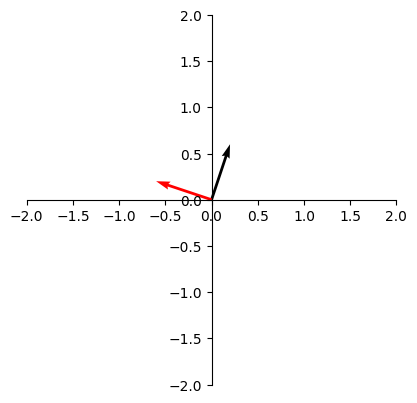

In [23]:
import numpy as np
import matplotlib.pyplot as plt


def plot_vector(ax, arr, c = 'k'):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    if len(arr)==2:
        plt.quiver([0], [0], [arr[0]], [arr[1]], angles='xy', scale_units='xy', scale=1, color=c)
                        
    else:
        return
    
A = np.array([[0, -1], [1, 0]])

x = np.array([0.2,0.6])
b = np.matmul(A,x)
## or simply 
# b = A@x

fig, ax = plt.subplots()
plot_vector(ax, x)
plot_vector(ax, b,'r')

plt.axis('square')
plt.xlim((-2,2))
plt.ylim((-2,2))
plt.show()


## Exercise 1

Write your own function to implement the multiplication of a vector by a matrix. You will often use the implementation of numpy, but it is useful to implement yourself at least once. 

Play around with different vectors, seeing how they all rotate 90 degrees, without any other change when multiplied by this matrix.


:::{note} Multiplication of matrices
One can also multiply a matrix by another matrix. This is similar to doing multiple matrix and vector multiplications and stacking the resulting vectors in a matrix as well. You can try to make your function also deal with this case as a challenge. 

Notice that the size of the resulting matrix is always defined by the size of the multiplying matrices. For instance, a n by m matrix A, multiplied by a p by q matrix B will result in the n by q matrix C. For the matrix multiplication to be possible, m and p must also be equal. 

Hence, the following multiplication is possible.

$A_{{\color{green}2} \times {\color{red}3}} * B_{{\color{red}3}\times{\color{green}5}} = C_{{\color{green}2}\times{\color{green}5}}$ 

But the opposite operation ($B*A$) is not valid.


:::

In [ ]:
def matrix_multiplication(A, x):
    # Your code goes here.

    return b


# Transposition, trace and determinants of a matrix

Given a matrix A, populated by elements $a_{ij}$, with $i$ representing the rows of the matrix and $j$ are its collumns, the transpose of A is the matrix $A^T$. The elements $a^t_{ij}$ of $A^T$ are such that an element in row i and column j in $A^T$ correspond to the element in row j and column i in $A$. In other words:

$a^t_{ij} = a_{ji}$

You can easily compute the transpose of a matrix `m` in numpy using `np.transpose(m)` or `m.T`. 

## Exercise 2

Write your own function that computes the traspose of a matrix.

:::{note} Inner product and outer product 
Now that we have defined the transpose of a matrix, we can do more easily do a matrix multiplication with two vectors. Given the 3-by-1 collumn vectors v and w, it's now possible to arrange them so that a matrix multiplication is possible. 

The first way of doing that is by computing:

$$v^T w $$ (dot_product3)

The resulting operation is a 1-by-1 (thus, a scalar). If you unpack the multiplications done in {eq}`dot_product3`, you will see that it's the exact same as the formula of the dot product in {eq}`dot_product3`.

One can also do the opposite operation, transposing the sencod vector to match the dimensionss. In that case, the result would be a 3-by-3 matrix. 

$$v w^T $$

This operation is known as the [outer product](wiki:outer_product) (in contrast with the inner product). The inner product of two vectors is actually the trace of their outer product (see the next exercise for the trace definition).

:::

In [ ]:
def matrix_transposition(A):
    # Your code goes here.

    return 


There are some other quantities associated to a matrix that are a single value, rather than another vector or matrix (like the transposition or outer product). One of these quantities is the trace. The trace of any square matrix can be defined as the sum of all the elements in the diagonal.

For every element $a_{ij}$ of a matrix $A$, the trace can be defined as

$ Tr = \sum_{i=j} {a_{ij}}$

where $i$ represents the row, and $j$ the collumns of $A$

## Exercise 3

Write the function `trace` that computes the trace of a 2D square matrix.




In [ ]:
def trace(m):


    return

Another important quantity that can be defined from a matrix $A$ is the determinant of the matrix. This quantity is related to, among other things, the linear system described by the matrix A. The linear system has a solution, if and only if the determinant of the matrix is different than 0. If the determinant of a matrix is 0, this matrix is said to be singular.

For a 2-by-2 square matrix $ A = \begin{bmatrix} a & b\\ c & d \end{bmatrix} $, the determinant $det(A)$ (or sometimes $|A|$) is defined by the formula:

$ det(A)  ad - bc $

Some interesting property of determinants are that:

$ det(AB) = det(A)det(B)$

And if A is a triangular matrix, det(A) is the product of its diagonal.


## Exercise 4

Write the function `determinant` that computes the determinant of any n-by-n triangular matrix, or of any 2-by-2 square matrix.


In [ ]:
def determinant(m):


    return

# Identity matrix and inverse matrix

Like addition and multiplication, the operation of matrix multiplication also has a "neutral" element. In the case of addition and multiplication, one can find the neutral element by finding the value x for which the following equations hold for any value of $a$:

$a+x = a$; and $ax = a$

It is easy to see that $x=0$ in the first case, and $x=1$ in the second. For matrix multiplication, the neutral element $I$ should satisty the equation:

$AI = A$

$I$, also known as the identity matrix, has all its elements in the main diagonal (the elements $a_{ij}$ where $i=j$) as 1, and all other elements as 0. For a given matrix $A$, the size of the corresponding identity matrix depends on the size of $A$. For instance, for a 3-by-3 matrix, $I_3$ is defined as:

 $ I_3 = \begin{bmatrix} 1 & 0 & 0\\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix} $

The identity matrix also help defining another important matrix, the inverse matrix. 

Just as -3 is the inverse of 3 regarding addition ($3-3 = 0$). And 0.5 is the inverse of 2 regarding multiplication (0.5*2=1). We can find the inverse matrix of $A$, represented as $A^{-1}$, such that:

$A A^{-1} = A^{-1}A = I$

Note that the determinant can also help defining if a matrix can be inverted. This is only the case when the determinant is different than 0.

## Exercise 5

Write a function `is_inverse()` that receive two arrays representing n-by-n matrices, and returns a True if those matrices are the inverse of each other, and False otherwise.

In [ ]:
def is_inverse(m1, m2):

    return True

:::{note} Challenge
The inverse of a matrix can be found by applying the [Gauss-Jordan elimination proccess](wiki:Gaussian_elimination).

Read about that method, and implement a function `invert()`, that uses this technique to find the inverse of matric.
:::